In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# dataset link
url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"

df = pd.read_csv(url)
df.head()

# Features & labels
X = df.drop("species", axis=1)
y = df["species"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [2]:
accuracies = []

for k in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K={k}  Accuracy={acc:.4f}")


K=1  Accuracy=0.9667
K=2  Accuracy=0.9333
K=3  Accuracy=0.9333
K=4  Accuracy=0.9333
K=5  Accuracy=0.9333
K=6  Accuracy=0.9333
K=7  Accuracy=0.9667
K=8  Accuracy=0.9333
K=9  Accuracy=0.9667
K=10  Accuracy=0.9667
K=11  Accuracy=0.9667
K=12  Accuracy=0.9667
K=13  Accuracy=0.9667
K=14  Accuracy=0.9333
K=15  Accuracy=0.9333


Accuracy: 0.9333333333333333


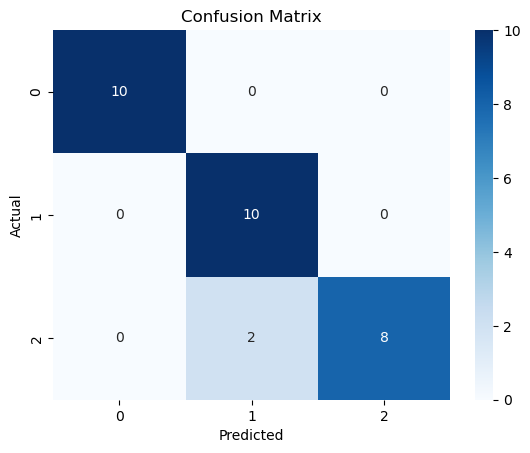

In [3]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

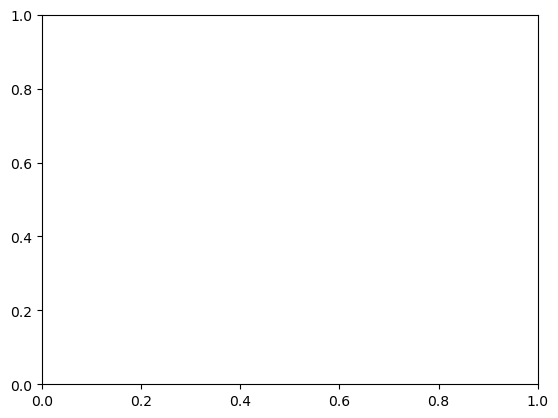

In [4]:
# take 2 features
X_vis = df[["sepal_length", "sepal_width"]]
y_vis = df["species"]

# normalize
Xv = scaler.fit_transform(X_vis)

# fit model
knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(Xv, y_vis)

# plot decision boundary
h = 0.02  
x_min, x_max = Xv[:, 0].min() - 1, Xv[:, 0].max() + 1
y_min, y_max = Xv[:, 1].min() - 1, Xv[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.5)
sns.scatterplot(x=Xv[:, 0], y=Xv[:, 1], hue=y_vis)
plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.title("KNN Decision Boundary")
plt.show()
